# Sales Forecasting Analysis

## Objective

The objective of this analysis is to forecast future sales performance based on historical order activity.

Forecasting helps businesses anticipate future demand, improve inventory planning, optimize staffing levels, and support strategic decision-making.

## Business Question

What are the expected future order volumes and revenue trends based on historical performance?

Specifically, we want to answer:

1. Are sales increasing or decreasing over time?
2. Are there seasonal patterns in customer purchases?
3. What are the expected sales levels in future periods?
4. How can the business use these forecasts for planning purposes?

## Why Are We Performing Forecasting?

Forecasting transforms historical data into future business expectations.

Organizations use forecasting to:

- Plan inventory levels
- Manage supplier relationships
- Allocate staffing resources
- Set sales targets
- Support budgeting decisions

By understanding future demand patterns, businesses can make proactive rather than reactive decisions.

## Forecast Metric Selection

Revenue is one of the most important business metrics because it directly reflects company performance.

For this analysis, we will forecast monthly revenue trends using historical payment data.

Forecasting revenue helps the business:

- Plan future inventory needs
- Establish sales targets
- Support budgeting decisions
- Identify growth opportunities
- Prepare for seasonal demand fluctuations

## Business Question

How has monthly revenue changed over time?

Before forecasting future revenue, we must first understand historical revenue trends.

## Why This Step Matters

Forecasting models require time-series data.

We will aggregate transaction-level revenue into monthly revenue totals to create a clean time series suitable for forecasting.

This step transforms individual customer payments into a business-level performance metric.

In [2]:
# Create a visualization to make the pattern easier to interpret.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [3]:
# Load dataset from CSV file into a pandas DataFrame.
DATA_DIR = Path("../data")

orders_df = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
payments_df = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")

In [4]:
payments_df.head(1)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33


In [5]:
orders_df.head(1)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00


In [6]:
# Merge orders with payments to obtain
# both purchase dates and revenue values.

revenue_df = orders_df.merge(
    payments_df[
        [
            "order_id",
            "payment_value"
        ]
    ],
    on="order_id",
    how="inner"
)

# Convert purchase timestamp to datetime.

revenue_df["order_purchase_timestamp"] = pd.to_datetime(
    revenue_df["order_purchase_timestamp"]
)

# Extract year-month for aggregation.

revenue_df["year_month"] = (
    revenue_df["order_purchase_timestamp"]
    .dt.to_period("M")
)

# Calculate monthly revenue.

monthly_revenue_df = (
    revenue_df
    .groupby("year_month", as_index=False)
    .agg(
        revenue=("payment_value", "sum")
    )
)

# Convert period back to timestamp.

monthly_revenue_df["year_month"] = (
    monthly_revenue_df["year_month"]
    .dt.to_timestamp()
)

monthly_revenue_df.head()

,year_month,revenue
0,2016-09-01,252.24
1,2016-10-01,59090.48
2,2016-12-01,19.62
3,2017-01-01,138488.04
4,2017-02-01,291908.01


In [7]:
#check the shape
monthly_revenue_df.shape


(25, 2)

In [8]:
monthly_revenue_df.head()


,year_month,revenue
0,2016-09-01,252.24
1,2016-10-01,59090.48
2,2016-12-01,19.62
3,2017-01-01,138488.04
4,2017-02-01,291908.01


In [9]:
monthly_revenue_df.tail()

,year_month,revenue
20,2018-06-01,1023880.50
21,2018-07-01,1066540.75
22,2018-08-01,1022425.32
23,2018-09-01,4439.54
24,2018-10-01,589.67


## Data Validation Before Forecasting

### Why Is Data Validation Important?

Forecasting models are highly sensitive to data quality. Before building a forecasting model, it is important to verify that the historical time series accurately represents business activity.

Incomplete or partial periods can distort trends and lead to misleading forecasts.

### Validation Checks Performed

Before forecasting monthly revenue, the following checks were performed:

1. Verify the number of available time periods.
2. Check for missing months in the time series.
3. Identify unusually low or high revenue values.
4. Determine whether the first or last months represent partial periods.
5. Confirm that the dataset reflects actual business performance rather than data collection limitations.

### Business Rationale

If incomplete months are included in the forecasting dataset, the model may incorrectly interpret temporary data gaps as genuine declines in business performance.

For example:

* A partially recorded final month may appear as a sharp revenue drop.
* A partially recorded first month may appear as unusually low sales activity.

These observations can bias the forecasting model and reduce prediction accuracy.

### Next Step

Review the monthly revenue series and determine whether any partial months should be excluded before training the forecasting model.


In [10]:
revenue_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,year_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,18.12,2017-10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2.00,2017-10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,18.59,2017-10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12,2018-08


In [11]:
#check all months
monthly_revenue_df

,year_month,revenue
0,2016-09-01,252.24
1,2016-10-01,59090.48
2,2016-12-01,19.62
3,2017-01-01,138488.04
4,2017-02-01,291908.01
5,2017-03-01,449863.60
6,2017-04-01,417788.03
7,2017-05-01,592918.82
8,2017-06-01,511276.38
9,2017-07-01,592382.92


### Observations During Validation

During the validation process, several months were flagged for further investigation because the reported revenue values were significantly lower than surrounding periods.

For example, December 2016 reported revenue of approximately $20, while neighboring months generated tens or hundreds of thousands of dollars in revenue.

From a business perspective, such a decline was unlikely to represent actual customer demand and suggested a potential data completeness issue.

This observation triggered additional validation checks before proceeding with forecasting.


## Preparing the Forecasting Dataset

After identifying incomplete and potentially unreliable reporting periods, those observations will be removed from the forecasting dataset.

The objective is to ensure that the forecasting model learns from representative business activity rather than data collection artifacts.

Using complete periods improves forecast reliability and reduces the risk of misleading predictions.

In [12]:
# Remove incomplete months from the forecasting dataset.

forecast_revenue_df = monthly_revenue_df[
    ~monthly_revenue_df["year_month"].isin(
        pd.to_datetime([
            "2016-09-01",
            "2016-12-01",
            "2018-09-01",
            "2018-10-01"
        ])
    )
].copy()

forecast_revenue_df


,year_month,revenue
1,2016-10-01,59090.48
3,2017-01-01,138488.04
4,2017-02-01,291908.01
5,2017-03-01,449863.60
6,2017-04-01,417788.03
7,2017-05-01,592918.82
8,2017-06-01,511276.38
9,2017-07-01,592382.92
10,2017-08-01,674396.32
11,2017-09-01,727762.45


In [13]:
revenue_df.groupby(
    revenue_df["order_purchase_timestamp"].dt.to_period("M")
).agg(
    order_count=("order_id", "nunique"),
    revenue=("payment_value", "sum")
)

,order_count,revenue
order_purchase_timestamp,,
2016-09,3,252.24
2016-10,324,59090.48
2016-12,1,19.62
2017-01,800,138488.04
2017-02,1780,291908.01
2017-03,2682,449863.60
2017-04,2404,417788.03
2017-05,3700,592918.82
2017-06,3245,511276.38


## Validation Findings

To validate whether unusually low revenue months represented actual business activity, monthly order counts were analyzed.

Several months contained extremely low order volumes compared with the rest of the dataset.

Examples include:

| Month   | Orders |
| ------- | -----: |
| 2016-09 |      3 |
| 2016-12 |      1 |
| 2018-09 |     16 |
| 2018-10 |      4 |

In comparison, typical months contained between 3,000 and 7,500 orders.

These findings suggest that the affected months represent incomplete reporting periods rather than genuine business performance.

As a result, these observations will be excluded from the forecasting dataset to improve model reliability.


In [14]:
forecast_revenue_df.shape

(21, 2)

#Magic SKLV During validation, I identified several anomalous months with extremely low order volumes. I investigated the underlying transactions and found that these periods contained only 1–16 orders compared with thousands in normal months, indicating incomplete reporting periods. I excluded them to improve forecast reliability.

sklm 

## Revenue Trend Analysis

### Business Question

Is the business generating more revenue over time, and what does this trend indicate about future business performance?

### Why This Analysis Matters

Before building a forecasting model, it is important to understand the historical revenue trend.

Revenue trends help businesses:

* Evaluate overall business growth
* Identify periods of strong or weak performance
* Detect unusual spikes or declines
* Support inventory and staffing planning
* Establish realistic sales targets

Understanding the historical trend provides context for forecasting and helps stakeholders interpret future predictions more effectively.

### Data Preparation

Prior to trend analysis, incomplete reporting periods were identified and removed from the dataset. These periods contained unusually low transaction volumes and revenue values that did not represent normal business activity.

Removing incomplete periods ensures that the analysis reflects actual business performance and improves the reliability of subsequent forecasts.

### Analysis Approach

Monthly revenue was calculated by aggregating transaction-level payment data into monthly totals.

This transformation converts individual customer purchases into a business-level performance metric that can be analyzed over time.

### Expected Outcome

The revenue trend analysis will help determine:

* Whether the business is growing, declining, or stable
* Whether there are noticeable seasonal patterns
* Whether any abnormal revenue spikes require further investigation
* Whether historical performance supports future growth expectations


## Visualizing Historical Revenue

### Business Question

How has revenue changed over time?

### Why This Analysis Matters

Forecasting models learn patterns from historical data. Before predicting future revenue, it is important to understand how the business has performed historically.

Visualizing revenue over time helps identify:

* Long-term growth trends
* Seasonal patterns
* Revenue spikes
* Revenue declines
* Potential anomalies

These observations provide context for future forecasts and support more informed business decisions.

### Expected Outcome

The revenue trend visualization will reveal whether the business is growing, declining, or remaining stable and whether any recurring patterns exist that may influence future performance.


### Forecast Visualization

The chart below compares historical revenue performance with projected future revenue generated by the forecasting model.

Black data points represent actual historical revenue observations, while the blue trend line represents the model's expected revenue forecast. The shaded region represents the forecast uncertainty interval, showing the range within which future revenue is expected to fall.

This visualization helps assess whether the projected business trajectory aligns with historical performance patterns and provides management with a visual estimate of future revenue growth.


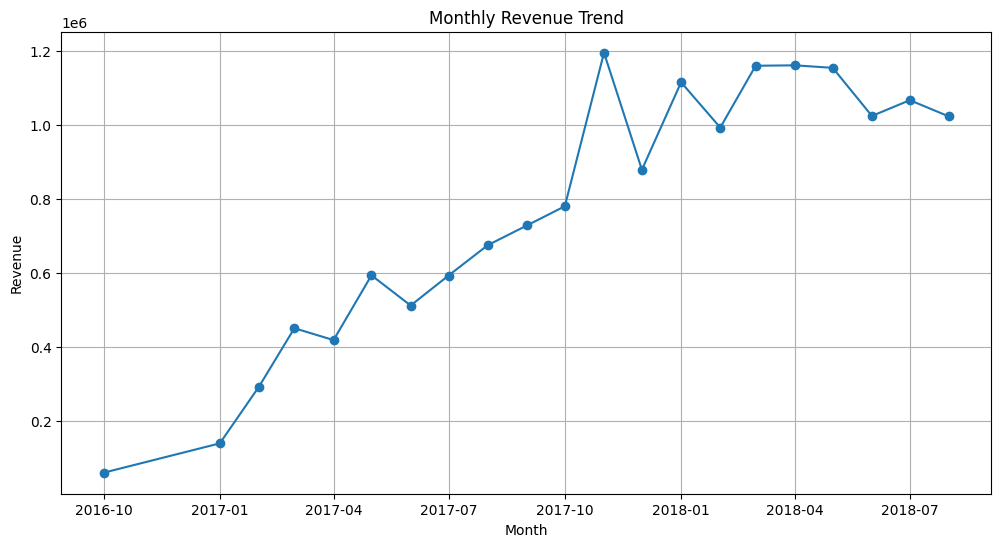

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    forecast_revenue_df["year_month"],
    forecast_revenue_df["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

### Business Interpretation

Revenue increased steadily throughout the analysis period, indicating growing customer demand and marketplace expansion.

### Management Recommendation

Management should investigate the drivers of growth and ensure operational capacity can support increasing demand.

## Revenue Trend Insights

The revenue trend shows strong business growth throughout the analysis period.

Monthly revenue increased from approximately $59,000 in late 2016 to more than $1 million per month during 2018. Although some month-to-month fluctuations are present, the overall trajectory remains positive.

The sustained revenue levels observed in 2018 suggest that the business successfully scaled its operations and maintained customer demand over time.

From a business perspective, these results indicate a healthy growth trend and provide a strong foundation for forecasting future revenue performance.


#Is the business growing, and what does that mean for future planning?

## Month-over-Month Revenue Growth Analysis

### Business Question

How quickly is revenue growing from one month to the next?

### Why This Analysis Matters

Revenue levels show how much money the business generates, but revenue growth rates reveal how quickly the business is expanding.

A growing business may require additional inventory, staffing, logistics capacity, and marketing investment. Conversely, slowing growth may indicate market saturation or emerging operational challenges.

Understanding revenue growth trends helps management evaluate business momentum and supports more accurate forecasting.

### Data Used

This analysis uses the validated monthly revenue dataset created during the previous steps.

Incomplete reporting periods were removed to ensure that growth calculations accurately reflect business performance.

### Analysis Approach

Month-over-month revenue growth is calculated by comparing each month's revenue to the previous month's revenue.

This metric helps identify:

* Periods of rapid expansion
* Periods of slowing growth
* Potential seasonal patterns
* Unusual changes in business performance

### Expected Outcome

The analysis will determine whether the business is experiencing:

* Consistent growth
* Slowing growth
* Accelerating growth
* Seasonal fluctuations

These findings will provide additional context for revenue forecasting and business planning.


In [17]:
# Calculate month-over-month revenue growth.

forecast_revenue_df["revenue_growth_pct"] = (
    forecast_revenue_df["revenue"]
    .pct_change()
    * 100
)

forecast_revenue_df[
    [
        "year_month",
        "revenue",
        "revenue_growth_pct"
    ]
].head(10)

,year_month,revenue,revenue_growth_pct
1,2016-10-01,59090.48,NaN
3,2017-01-01,138488.04,134.366077
4,2017-02-01,291908.01,110.782108
5,2017-03-01,449863.60,54.111427
6,2017-04-01,417788.03,-7.130066
7,2017-05-01,592918.82,41.918575
8,2017-06-01,511276.38,-13.769581
9,2017-07-01,592382.92,15.863541
10,2017-08-01,674396.32,13.844660
11,2017-09-01,727762.45,7.913170


## Key Findings

The business experienced substantial revenue growth throughout the analysis period.

Month-over-month growth exceeded 100% during the early stages of the business, indicating rapid expansion. Although growth rates gradually declined over time, revenue continued to increase overall.

Several months exhibited temporary declines in growth; however, the long-term trend remained positive.

## Business Interpretation

The declining growth rate does not necessarily indicate worsening business performance. Instead, it suggests that the business is maturing and growing from a larger revenue base.

As organizations scale, maintaining extremely high growth rates becomes increasingly difficult. The continued increase in revenue levels indicates that customer demand remains strong.

## Recommendation

Management should continue monitoring growth trends and investigate opportunities to sustain long-term expansion through customer acquisition, product diversification, and operational improvements.


## Executive Summary

The revenue trend shows that the business grew significantly during the analysis period.

Monthly revenue increased from approximately $59,000 in late 2016 to over $1 million during 2018. This indicates that the business was able to attract more customers and generate higher sales over time.

I also observed that revenue growth rates were much higher during the early stages of the business and gradually decreased over time. However, despite the lower growth percentages, total revenue continued to increase.

From a business perspective, this suggests that the company is still growing, but is beginning to transition from a rapid expansion phase to a more mature stage of growth.

Overall, the results indicate a healthy business with strong customer demand and positive revenue performance. To sustain future growth, management should continue monitoring customer acquisition, customer retention, and sales performance.


## Forecasting Preparation

### Business Question

Can historical revenue trends be used to estimate future business performance?

### Why This Analysis Matters

Revenue forecasting helps organizations anticipate future demand, allocate resources effectively, and establish realistic business targets.

By analyzing historical revenue patterns, management can make more informed decisions regarding inventory planning, staffing requirements, budgeting, and growth initiatives.

### Data Used

This analysis uses the validated monthly revenue dataset created in previous steps.

Incomplete reporting periods were removed to improve forecast reliability and ensure that the model is trained on representative business performance.

### Analysis Approach

The forecasting model will use historical monthly revenue data to identify trends and estimate future revenue levels.

The objective is not to predict exact revenue values but rather to provide a reasonable estimate of future business performance based on historical patterns.

### Expected Outcome

The forecast will provide visibility into potential future revenue trends and support strategic business planning.


### Understanding the Time Dimension

Forecasting models require two key pieces of information:

1. When an event occurred.
2. The value that occurred at that time.

In this analysis, the monthly purchase date serves as the time dimension, while monthly revenue serves as the metric being forecasted.

The time dimension allows the model to identify historical patterns, growth trends, and potential seasonality. Without a time dimension, the model would be unable to determine how business performance changes over time.

For this reason, the monthly revenue dataset is prepared in a format that explicitly identifies the date and revenue columns before training the forecasting model.


In [18]:
# Prophet requires two specific column names:
# ds = time dimension (date column)
# y = target variable to forecast (monthly revenue)

# Rename columns to match Prophet's required structure
forecast_prophet_df = forecast_revenue_df.rename(
    columns={
        "year_month": "ds",
        "revenue": "y"
    }
)

# Verify that the dataset is ready for forecasting
forecast_prophet_df.head()

,ds,y,revenue_growth_pct
1,2016-10-01,59090.48,NaN
3,2017-01-01,138488.04,134.366077
4,2017-02-01,291908.01,110.782108
5,2017-03-01,449863.60,54.111427
6,2017-04-01,417788.03,-7.130066


## Preparing the Forecasting Dataset

### Business Question

What information does the forecasting model need to predict future revenue?

### Why This Analysis Matters

Forecasting models learn patterns from historical business performance.

To estimate future revenue, the model must understand:

* When revenue occurred
* How much revenue occurred

Providing this information in a structured format allows the model to identify trends and generate future revenue estimates.

### Data Preparation

The forecasting dataset contains:

* ds: Monthly reporting period (time dimension)
* y: Monthly revenue (target variable)

Additional analytical metrics such as revenue growth rates were retained for business interpretation but are not required for model training.

### Expected Outcome

The prepared dataset will allow the forecasting model to learn historical revenue patterns and estimate future business performance.


In [19]:
# Verify the final dataset size after data cleaning and preparation
forecast_prophet_df.shape

(21, 3)

### Dataset Validation Check

The final forecasting dataset contains 21 monthly observations after data cleaning and validation.

This confirms that the incomplete reporting periods identified during exploratory analysis were successfully removed while preserving the majority of the historical revenue data.

The resulting dataset provides a clean historical record of business performance that can be used for forecasting future revenue trends.


In [20]:
# Verify the final dataset size after data cleaning and preparation
forecast_prophet_df.shape

(21, 3)

In [21]:
from prophet import Prophet

print("Prophet imported successfully")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Prophet imported successfully


In [22]:
# Initialize the Prophet forecasting model.
# The model will learn patterns from historical monthly revenue.

model = Prophet()

# Train the model using the validated monthly revenue data.
# Only ds and y are used because Prophet needs:
# ds = date column
# y = revenue value to forecast

model.fit(
    forecast_prophet_df[
        ["ds", "y"]
    ]
)

03:03:59 - cmdstanpy - INFO - Chain [1] start processing
03:04:00 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
# Create future monthly dates for the next 6 months.
# This allows the model to estimate future revenue beyond the historical data.
#means month start, so the future dates will follow the same monthly structure as your historical data.

future_df = model.make_future_dataframe(
    periods=6,
    freq="MS"
)

future_df.tail(10)

,ds
17,2018-05-01
18,2018-06-01
19,2018-07-01
20,2018-08-01
21,2018-09-01
22,2018-10-01
23,2018-11-01
24,2018-12-01
25,2019-01-01
26,2019-02-01


## Creating Future Forecast Periods

### Business Question

For which future periods should revenue be estimated?

### Why This Analysis Matters

A forecasting model can only generate predictions for periods that are explicitly provided.

To estimate future business performance, additional monthly periods must be created beyond the historical revenue data.

### Analysis Approach

Six future monthly periods were added to the forecasting dataset.

These periods represent future business activity for which historical revenue does not yet exist. The forecasting model will generate estimated revenue values for each of these months based on patterns learned from historical performance.

### Expected Outcome

The model will produce projected revenue values for the next six months, providing management with visibility into potential future business performance.


In [27]:
# Generate forecasted revenue values using the trained model
forecast = model.predict(future_df)

# Display:
# yhat = predicted revenue
# yhat_lower = lower forecast bound
# yhat_upper = upper forecast bound

forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(10)

,ds,yhat,yhat_lower,yhat_upper
17,2018-05-01,1.125658e+06,9.531953e+05,1.289220e+06
18,2018-06-01,1.178080e+06,1.017052e+06,1.351148e+06
19,2018-07-01,1.228811e+06,1.047667e+06,1.410772e+06
20,2018-08-01,1.281233e+06,1.124774e+06,1.456412e+06
21,2018-09-01,1.333655e+06,1.169349e+06,1.496908e+06
22,2018-10-01,1.384386e+06,1.218702e+06,1.564143e+06
23,2018-11-01,1.436808e+06,1.264427e+06,1.617635e+06
24,2018-12-01,1.487539e+06,1.320206e+06,1.665125e+06
25,2019-01-01,1.539961e+06,1.371994e+06,1.715582e+06
26,2019-02-01,1.592383e+06,1.423029e+06,1.764799e+06


yhat_lower  ← conservative estimate
yhat        ← expected estimate
yhat_upper  ← optimistic estimate
The model estimates the most likely future revenue, but because future business performance is uncertain, it also provides a lower and upper range. This helps management plan for best-case and conservative scenarios instead of relying on one exact number.

## Forecast Results and Business Interpretation

### Key Findings

The forecasting model predicts continued revenue growth throughout the six-month forecast period.

Projected monthly revenue increases from approximately $1.33 million in September 2018 to approximately $1.59 million by February 2019.

The forecast does not indicate any significant decline or stagnation in business performance during the projected period.

### Business Interpretation

The results suggest that historical growth patterns are expected to continue in the near future.

If customer demand, operational performance, and market conditions remain consistent with historical trends, the business is likely to maintain positive revenue growth over the forecast horizon.

Although forecasting models cannot predict future events with complete certainty, the overall trend indicates strong business momentum and continued expansion.

### Management Recommendation

Management should use the forecast as a planning tool for budgeting, inventory management, staffing requirements, and growth initiatives.

Because revenue is expected to increase, the organization should ensure that operational capacity can support future demand while continuing to monitor actual performance against forecasted results.


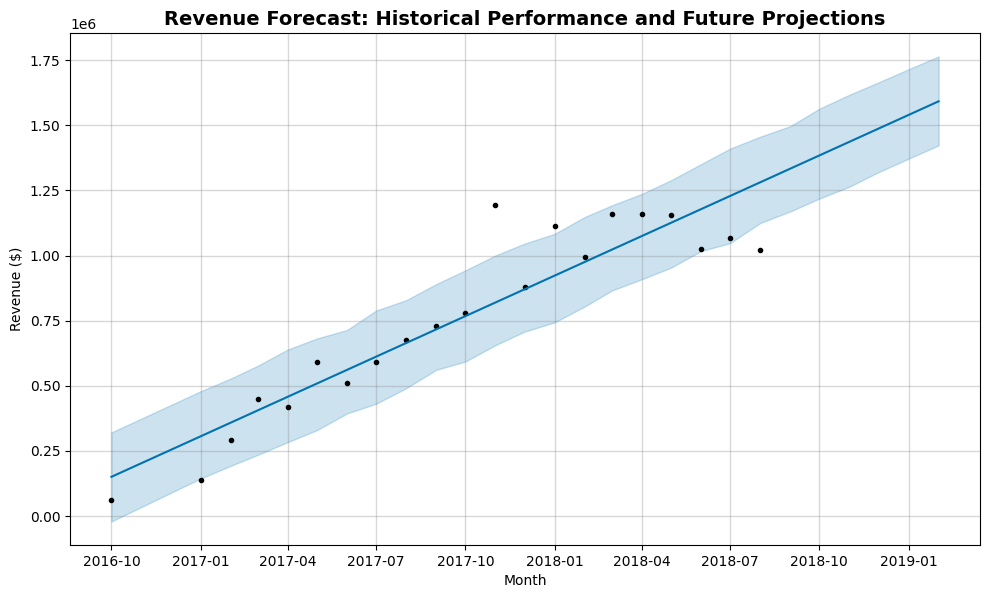

In [31]:
# Visualize historical revenue and future forecast

# Create forecast visualization
fig = model.plot(forecast)

# Improve chart readability
import matplotlib.pyplot as plt

plt.title(
    "Revenue Forecast: Historical Performance and Future Projections",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.grid(True, alpha=0.3)

plt.show()

## Forecast Visualization

### Business Question

Does the forecasted revenue trend align with historical business performance?

### Why This Analysis Matters

Visualizing the forecast allows us to compare historical revenue performance with projected future revenue.

This helps validate whether the forecast is reasonable and whether the predicted business trajectory aligns with observed historical trends.

### Key Observations

The forecast indicates a continued upward revenue trend throughout the forecast horizon.

Most historical observations remain relatively close to the forecast trend line, suggesting that the model captures the overall direction of business growth.

The shaded forecast interval becomes wider as the forecast extends further into the future. This reflects increasing uncertainty, which is expected in forecasting models.

### Business Interpretation

The visualization suggests that the business is expected to maintain positive revenue growth if historical performance patterns continue.

While future revenue cannot be predicted with complete certainty, the forecast does not indicate signs of declining demand or revenue contraction.

The increasing uncertainty range highlights the importance of regularly comparing actual business performance against forecasted results.

### Management Recommendation

Management should use the forecast as a planning tool rather than an exact prediction.

Actual performance should be monitored against forecasted revenue to identify emerging trends, operational changes, or market conditions that may influence future growth.


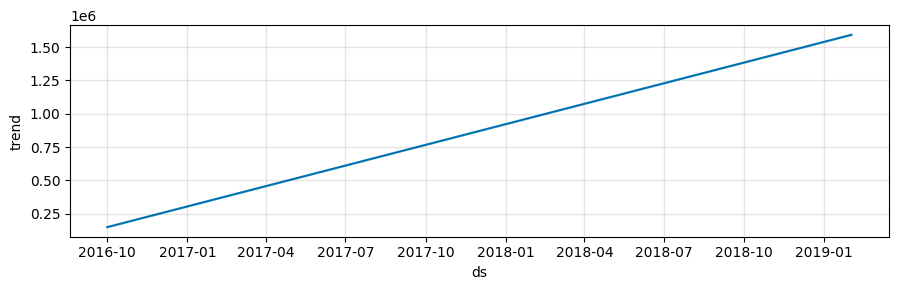

In [29]:
# Visualize the components learned by the forecasting model

# This chart helps explain WHY the model is making its predictions
# and whether the forecast is driven by long-term trends or seasonal patterns.

fig2 = model.plot_components(forecast)

# Conclusion

The purpose of this analysis was to determine whether historical revenue trends could be used to estimate future business performance.

After validating the revenue data and removing incomplete reporting periods, I analyzed monthly revenue trends and growth rates before developing a forecasting model using Prophet.

The analysis revealed a strong and consistent upward revenue trend throughout the historical period. Revenue increased from approximately $59,000 per month in late 2016 to more than $1 million per month during 2018.

The forecasting model predicts that this growth trend will continue over the next six months, with projected revenue increasing from approximately $1.33 million to $1.59 million.

The component analysis showed that the forecast is primarily driven by long-term business growth rather than seasonal effects. No strong recurring seasonal patterns were identified within the available historical data.

Overall, the results suggest that the business is positioned for continued growth if historical performance patterns remain consistent.


# Executive Summary

The objective of this analysis was to forecast future revenue using historical marketplace performance data.

During the analysis, I first validated the revenue dataset and identified incomplete reporting periods that could distort business conclusions. After removing these periods, I analyzed historical revenue performance and observed a strong long-term growth trend.

I then developed a forecasting model to estimate future revenue performance. The forecast projects continued business growth, with revenue increasing from approximately $1.33 million to $1.59 million over the next six months.

One of the most important findings was that future revenue projections are primarily driven by sustained business growth rather than recurring seasonal patterns. This indicates that the business has been expanding consistently over time and that customer demand remains strong.

From a business perspective, the forecast suggests positive momentum and provides management with a data-driven estimate of future revenue performance that can support planning and decision-making activities.


# Management Recommendations

1. Use the forecast as a planning tool for budgeting, staffing, inventory management, and operational capacity planning.

2. Monitor actual revenue performance against forecasted values on a monthly basis to identify emerging trends and potential deviations from expected growth.

3. Continue investing in customer acquisition and retention initiatives to support the growth trajectory identified by the forecasting model.

4. Rebuild and retrain forecasting models as additional historical data becomes available to improve forecast accuracy and identify potential seasonal patterns.

5. Combine forecasting results with customer segmentation, CLV analysis, and funnel analysis to support more comprehensive strategic planning and revenue optimization initiatives.
